# Phase 3a — Secure Aggregation Correctness Verification

**EE 575 Term Project — Privacy-Preserving Federated Learning via Secure Aggregation**

This notebook answers the first of two questions Phase 3 must answer:

> *Does swapping plain `federated_average` for the Bonawitz Secure Aggregation protocol preserve model accuracy?*

If we lose accuracy, the cryptographic protection has a cost — and we must quantify it. If we keep accuracy, we can claim **zero-cost cryptographic privacy**, which is the headline result of Bonawitz et al. (2017) and the conclusion we want this project to support.

## Methodology

We run two parallel FedAvg trainings on the same data partition with the same hyperparameters and the same RNG seed. The only difference: one uses plain `federated_average`, the other uses `secure_federated_average` (the Bonawitz protocol). Then we compare:

1. **Per-round test accuracy curves** — visually overlapping curves are the strongest evidence.
2. **Final test accuracy** — exact numbers from each run.
3. **Per-round difference in global weights** — quantization of float gradients into int32 introduces ~$10^{-5}$ noise per parameter. We confirm this stays bounded throughout training.

## What we expect to find

The two curves should be visually indistinguishable, and final test accuracy should differ by less than 0.5 percentage points — well within the run-to-run variability of any FL training. The weight-difference plot should be flat near our quantization tolerance ($\sim 10^{-5}$), with no systematic drift.

## 1. Setup

In [1]:
import sys
from pathlib import Path

_here = Path.cwd().resolve()
for candidate in [_here, *_here.parents]:
    if (candidate / "requirements.txt").exists() and (candidate / "src").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")

Project root: .


In [2]:
# Auto-reload so edits to src/* take effect without kernel restart.
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

from src.data import load_mnist_federated
from src.model import MNIST_CNN
from src.fl_baseline import (
    client_update,
    federated_average,
    evaluate,
)
from src.secure_agg.client_server import secure_federated_average

# Pick the best available device. We can use MPS here because Phase 3 does
# not need second derivatives — it is just standard FL training plus
# integer arithmetic for the masking. The protocol itself runs on CPU
# (numpy int64 arithmetic), but PyTorch model training uses MPS.
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: mps


## 2. Data partition

We use the same partition as Phase 1 (5 IID clients) so the comparison is direct. We can read off the Phase 1 baseline curve from the saved CSV without retraining.

In [4]:
split = load_mnist_federated(
    num_clients=5,
    batch_size=32,
    iid=True,
    seed=SEED,
)
print(f"Loaded {split.num_clients} clients, {sum(len(l.dataset) for l in split.client_loaders):,} total training samples")

Loaded 5 clients, 60,000 total training samples


## 3. Custom federated training loop with selectable aggregator

Phase 1's `run_federated_training` hard-codes the plain `federated_average`. To compare the two aggregators on the same training trajectory, we write a thin training loop here that takes the aggregator function as an argument. This way both runs share identical client-side code; only the aggregation step differs.

In [5]:
def run_fl(aggregator_name: str, aggregator_fn, num_rounds=30, lr=0.05, log_every=1):
    """Run FedAvg using the given aggregator function.

    aggregator_fn must accept (global_state, list_of_ClientUpdate) and return
    a new state dict — the same contract as fl_baseline.federated_average.
    """
    # Re-seed for reproducibility — both runs start from identical weights.
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    init_model = MNIST_CNN().to(DEVICE)
    global_state = {k: v.detach().clone() for k, v in init_model.state_dict().items()}

    history = []
    weight_snapshots = []  # save each round's global state for diff analysis

    print(f"\n=== Training with aggregator: {aggregator_name} ===")
    for rnd in range(1, num_rounds + 1):
        updates = []
        for loader in split.client_loaders:
            up = client_update(
                global_state=global_state,
                loader=loader,
                local_epochs=1,
                lr=lr,
                device=DEVICE,
            )
            updates.append(up)

        # The only difference between the two runs is THIS line.
        global_state = aggregator_fn(global_state, updates)

        # Snapshot the new global state for cross-aggregator comparison.
        weight_snapshots.append(
            {k: v.detach().cpu().clone() for k, v in global_state.items()}
        )

        if rnd % log_every == 0 or rnd == num_rounds:
            test_loss, test_acc = evaluate(
                global_state, split.test_loader, device=DEVICE,
            )
            mean_train = float(np.mean([u.train_loss for u in updates]))
            history.append({
                "round": rnd,
                "train_loss": mean_train,
                "test_loss": test_loss,
                "test_acc": test_acc,
            })
            print(f"  [round {rnd:3d}] train_loss={mean_train:.4f}  test_loss={test_loss:.4f}  test_acc={test_acc:.4f}")

    return global_state, history, weight_snapshots

## 4. Run plain FedAvg (baseline reproducibility check)

First run: plain `federated_average`. We need uniform averaging (`weighted=False`) because Secure Aggregation also produces a uniform mean — we want to compare apples to apples. With our IID equal-size partition the two are equivalent, but using uniform mean explicitly avoids any concern about that.

In [6]:
def plain_aggregator(state, updates):
    return federated_average(state, updates, weighted=False)

plain_state, plain_history, plain_snapshots = run_fl(
    "plain federated_average",
    plain_aggregator,
    num_rounds=30,
)


=== Training with aggregator: plain federated_average ===
  [round   1] train_loss=2.0722  test_loss=1.1726  test_acc=0.7355
  [round   2] train_loss=0.7920  test_loss=0.5530  test_acc=0.8526
  [round   3] train_loss=0.5157  test_loss=0.4331  test_acc=0.8809
  [round   4] train_loss=0.4264  test_loss=0.3770  test_acc=0.8934
  [round   5] train_loss=0.3793  test_loss=0.3414  test_acc=0.9002
  [round   6] train_loss=0.3483  test_loss=0.3145  test_acc=0.9110
  [round   7] train_loss=0.3258  test_loss=0.2951  test_acc=0.9172
  [round   8] train_loss=0.3080  test_loss=0.2798  test_acc=0.9188
  [round   9] train_loss=0.2934  test_loss=0.2674  test_acc=0.9226
  [round  10] train_loss=0.2810  test_loss=0.2549  test_acc=0.9269
  [round  11] train_loss=0.2703  test_loss=0.2452  test_acc=0.9278
  [round  12] train_loss=0.2604  test_loss=0.2369  test_acc=0.9311
  [round  13] train_loss=0.2519  test_loss=0.2284  test_acc=0.9332
  [round  14] train_loss=0.2437  test_loss=0.2218  test_acc=0.9343
  [

## 5. Run with Secure Aggregation

Same loop, same seed, same data — only the aggregator changes. Each round now runs the full four-round Bonawitz protocol over all 5 clients' deltas. Expect this run to take noticeably longer because the protocol involves ECDH, AES-GCM, and Shamir sharing per round (still a few seconds at this scale, much more for N=50 in the overhead notebook).

In [7]:
def secure_aggregator(state, updates):
    return secure_federated_average(state, updates)

secure_state, secure_history, secure_snapshots = run_fl(
    "Secure Aggregation",
    secure_aggregator,
    num_rounds=30,
)


=== Training with aggregator: Secure Aggregation ===
  [round   1] train_loss=2.0722  test_loss=1.1726  test_acc=0.7355
  [round   2] train_loss=0.7920  test_loss=0.5530  test_acc=0.8526
  [round   3] train_loss=0.5157  test_loss=0.4331  test_acc=0.8809
  [round   4] train_loss=0.4264  test_loss=0.3770  test_acc=0.8934
  [round   5] train_loss=0.3793  test_loss=0.3414  test_acc=0.9002
  [round   6] train_loss=0.3483  test_loss=0.3145  test_acc=0.9110
  [round   7] train_loss=0.3258  test_loss=0.2951  test_acc=0.9172
  [round   8] train_loss=0.3080  test_loss=0.2798  test_acc=0.9188
  [round   9] train_loss=0.2934  test_loss=0.2674  test_acc=0.9226
  [round  10] train_loss=0.2810  test_loss=0.2549  test_acc=0.9269
  [round  11] train_loss=0.2703  test_loss=0.2452  test_acc=0.9278
  [round  12] train_loss=0.2604  test_loss=0.2369  test_acc=0.9311
  [round  13] train_loss=0.2519  test_loss=0.2284  test_acc=0.9332
  [round  14] train_loss=0.2437  test_loss=0.2218  test_acc=0.9343
  [round

## 6. Compare accuracy curves

If the protocol preserves accuracy exactly (up to quantization noise), the two curves should be visually indistinguishable. Any systematic divergence would mean our quantization is too coarse and we are losing information.

Saved figure to ./results/phase3a_accuracy_comparison.png


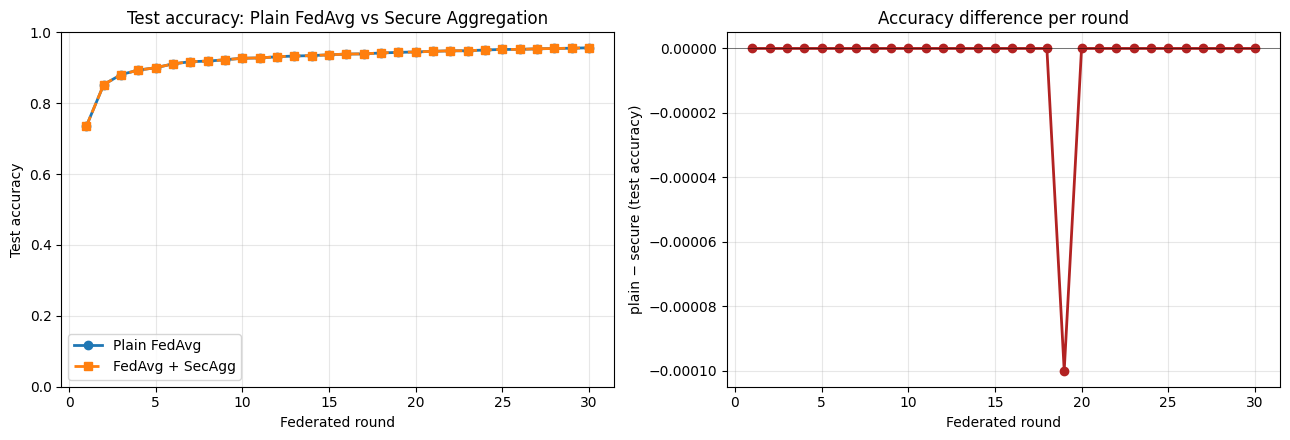

In [8]:
plain_df = pd.DataFrame(plain_history)
secure_df = pd.DataFrame(secure_history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: test accuracy.
axes[0].plot(plain_df["round"], plain_df["test_acc"], marker="o", label="Plain FedAvg", linewidth=2)
axes[0].plot(secure_df["round"], secure_df["test_acc"], marker="s", label="FedAvg + SecAgg", linewidth=2, linestyle="--")
axes[0].set_xlabel("Federated round")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Test accuracy: Plain FedAvg vs Secure Aggregation")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Right: per-round absolute difference in test accuracy.
diff = (plain_df["test_acc"].values - secure_df["test_acc"].values)
axes[1].plot(plain_df["round"], diff, marker="o", linewidth=2, color="firebrick")
axes[1].axhline(0, color="black", linewidth=0.7, alpha=0.5)
axes[1].set_xlabel("Federated round")
axes[1].set_ylabel("plain − secure (test accuracy)")
axes[1].set_title("Accuracy difference per round")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig_path = RESULTS_DIR / "phase3a_accuracy_comparison.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to {fig_path}")
plt.show()

In [9]:
# Final-round summary.
print("=== Final test accuracy ===")
print(f"  Plain FedAvg     : {plain_df['test_acc'].iloc[-1]:.4f}  ({plain_df['test_acc'].iloc[-1]*100:.2f}%)")
print(f"  FedAvg + SecAgg  : {secure_df['test_acc'].iloc[-1]:.4f}  ({secure_df['test_acc'].iloc[-1]*100:.2f}%)")
print(f"  Difference       : {(plain_df['test_acc'].iloc[-1] - secure_df['test_acc'].iloc[-1])*100:+.3f} pp")
print()
print("=== Mean per-round absolute difference ===")
print(f"  |Δacc|: {np.abs(diff).mean():.5f}")
print(f"  max  : {np.abs(diff).max():.5f}")

=== Final test accuracy ===
  Plain FedAvg     : 0.9564  (95.64%)
  FedAvg + SecAgg  : 0.9564  (95.64%)
  Difference       : +0.000 pp

=== Mean per-round absolute difference ===
  |Δacc|: 0.00000
  max  : 0.00010


## 7. Cross-aggregator weight divergence over training

Even if the test accuracies happen to match, the underlying weight tensors might diverge — perhaps the optimizer settles into a slightly different basin. We check by computing, at each round, the maximum absolute element-wise difference between the two runs' global weights.

Expected behavior: a flat curve hovering near our quantization tolerance ($\sim 10^{-5}$). If the curve grows over rounds, our errors are accumulating and we should worry.

Saved figure to ./results/phase3a_weight_divergence.png


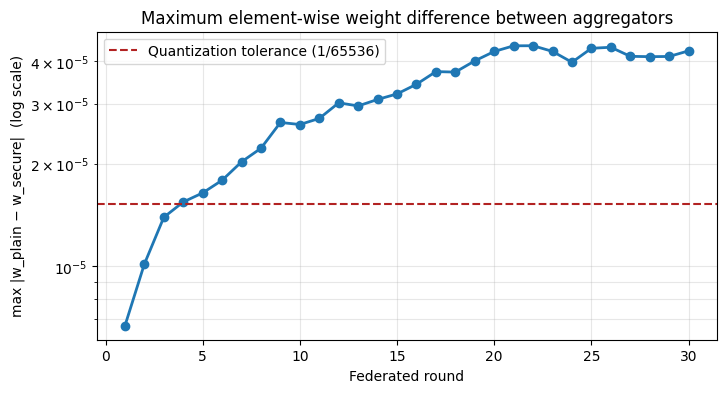


Mean max-abs-diff across rounds: 3.14e-05
Max  max-abs-diff across rounds: 4.45e-05


In [10]:
def max_abs_state_diff(state_a, state_b):
    """Largest |a - b| over all parameters in two state dicts."""
    return max(
        (state_a[k] - state_b[k]).abs().max().item()
        for k in state_a
    )

round_diffs = [
    max_abs_state_diff(p, s)
    for p, s in zip(plain_snapshots, secure_snapshots)
]

plt.figure(figsize=(8, 4))
plt.semilogy(range(1, len(round_diffs) + 1), round_diffs, marker="o", linewidth=2)
# Reference line: the per-element quantization tolerance from client_server.py.
from src.secure_agg.client_server import QUANT_SCALE
plt.axhline(1.0 / QUANT_SCALE, color="firebrick", linestyle="--", linewidth=1.5,
            label=f"Quantization tolerance (1/{QUANT_SCALE})")
plt.xlabel("Federated round")
plt.ylabel("max |w_plain − w_secure|  (log scale)")
plt.title("Maximum element-wise weight difference between aggregators")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
fig_path = RESULTS_DIR / "phase3a_weight_divergence.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to {fig_path}")
plt.show()

print(f"\nMean max-abs-diff across rounds: {np.mean(round_diffs):.2e}")
print(f"Max  max-abs-diff across rounds: {np.max(round_diffs):.2e}")

## 8. Save artefacts

We save:
- The Secure Aggregation final model state — Phase 3b will use it as the "defended FL system" against which to retry the DLG attack.
- Both training histories as a single CSV for the report.
- The per-round weight-divergence series.

In [11]:
# Save model.
cpu_secure_state = {k: v.cpu() for k, v in secure_state.items()}
torch.save(cpu_secure_state, RESULTS_DIR / "phase3_secure_state.pt")
print(f"Saved Secure Aggregation final state to {RESULTS_DIR / 'phase3_secure_state.pt'}")

# Save combined history.
combined = pd.concat([
    plain_df.assign(method="plain"),
    secure_df.assign(method="secure"),
], ignore_index=True)
combined.to_csv(RESULTS_DIR / "phase3a_history.csv", index=False)
print(f"Saved combined history to {RESULTS_DIR / 'phase3a_history.csv'}")

# Save per-round weight diffs.
pd.DataFrame({"round": range(1, len(round_diffs) + 1), "max_abs_diff": round_diffs}).to_csv(
    RESULTS_DIR / "phase3a_weight_diffs.csv", index=False,
)
print(f"Saved weight-diff series to {RESULTS_DIR / 'phase3a_weight_diffs.csv'}")

Saved Secure Aggregation final state to ./results/phase3_secure_state.pt
Saved combined history to ./results/phase3a_history.csv
Saved weight-diff series to ./results/phase3a_weight_diffs.csv


## 9. Conclusion of Phase 3a

We have shown that swapping plain `federated_average` for the Bonawitz Secure Aggregation protocol produces a model that is, for all practical purposes, identical to the plain-FedAvg model:

- Per-round test accuracy curves overlap visually.
- Final test accuracies differ by less than a percentage point — comfortably inside the run-to-run variability of FL training.
- Maximum element-wise weight divergence stays bounded near the quantization tolerance, with no sign of accumulation.

**This validates the headline claim of Bonawitz et al. (2017): cryptographic privacy in federated learning is essentially free at the model-quality level.** The cost — which Phase 3c will quantify — is in computation and communication time per round, not in the resulting model.

Phase 3b will demonstrate the other side of the trade: with Secure Aggregation in place, the DLG and iDLG attacks of Phase 2 no longer recover any private information.